In [107]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import nlopt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error




%load_ext autoreload
%autoreload 2

# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *
from src.nominal_speed_func import *

#feet を　メートルに変換する係数 1feet=0.3048m
FT_TO_M = 0.3048

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### データの読み込みとフィルタリングと名目速度関数の推定

In [2]:
# データの読み込みと前処理
df = load_trajectory_data()

#　フリッカリングノイズを除去
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=10)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=10) 

# ① ペアID付与
df_with_pairs = give_pair_id(df_clean)

# ② モードID付与
df_with_mode = give_mode_id(df_with_pairs, df)

# ③ 追従していない行を除外 追従している車両のみのデータが完成
df_valid = filter_valid_pairs(df_with_mode)

# ④ 車線フィルタ（Lanes 2, 3, 4のみ）
df_lane = filter_lane(df_valid)

# ⑤ モードフィルタ
df_mode = filter_mode(df_lane)

# ⑥ 追従時間フィルタ
df_duration = filter_duration(df_mode)

# ⑧ カットオフウィンドウ
df_cutoff = apply_cutoff(df_duration)

# ⑦ 加速度フィルタ
df_final = filter_acceleration(df_cutoff).copy()


# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")
assign_and_count_pair_type_with_pair_id(df_final)

(4566387, 19)

--フリッカリング除去--
補正されたブロック数: 671
行数: 4,566,387

--フリッカリング除去--
補正されたブロック数: 142
行数: 4,566,387

--ペアIDを付与--
総行数: 4,566,387
追従ペア数: 13,827

--モードID別を付与--
総行数: 4,566,387
追従ペア数: 13,827
mode_id
1.0    12337
2.0      438
3.0      549
4.0       42
5.0      461
dtype: int64

--追従していない軌跡データを削除--
フィルタ前の行数: 4,566,387
フィルタ後の行数: 4,359,245
除外された行数: 207,142
ペア数: 13,827

--車線フィルタ(2,3,4レーンを残す)--
フィルタ前: 4,359,245行
フィルタ後: 2,338,830行
除外された行数: 2,020,415行
追従ペア数: 5,780

車線の分布:
Lane_ID
2.0    800339
3.0    689350
4.0    849141
Name: count, dtype: int64

--車種フィルタ(1,2,3,4の追従モードを残す)--
フィルタ前のペア数: 5,780
フィルタ後のペア数: 5,666
除外されたペア数: 114
フィルタ後行数: 2,335,438行

モードID別ペア数:
mode_id
1.0    5067
2.0     237
3.0     326
4.0      36
dtype: int64

--追従時間フィルタ--
フィルタ前のペア数: 5,666
フィルタ後のペア数: 1,570
除外されたペア数: 4,096
フィルタ前の行数: 2,335,438
フィルタ後の行数: 1,487,854

--カットオフウィンドウ--
カットオフ前の行数: 1,487,854
カットオフ後の行数: 1,173,854
除外された行数: 314,000
カットオフ前のペア数: 1,570
カットオフ後のペア数: 1,570

--加速度フィルタ--
フィルタ前の行数: 1,173,854
フィルタ後の行数: 881,448
除外された行数: 29

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,...,Preceding,Following,Space_Headway,Time_Headway,time_period,pair_id,leader_class,ego_class,mode_id,pair_type
100,11,157,864,1113433150600,15.236,130.989,6042830.240,2133199.574,17.3,8.4,...,1.0,0,43.76,5.83,1,17.0,2.0,2,1.0,C-C
101,11,158,864,1113433150700,15.212,131.739,6042830.123,2133200.315,17.3,8.4,...,1.0,0,44.06,5.87,1,17.0,2.0,2,1.0,C-C
102,11,159,864,1113433150800,15.188,132.489,6042830.006,2133201.056,17.3,8.4,...,1.0,0,44.36,5.91,1,17.0,2.0,2,1.0,C-C
103,11,160,864,1113433150900,15.163,133.239,6042829.889,2133201.797,17.3,8.4,...,1.0,0,44.66,5.95,1,17.0,2.0,2,1.0,C-C
104,11,161,864,1113433151000,15.139,133.990,6042829.772,2133202.539,17.3,8.4,...,1.0,0,44.96,5.99,1,17.0,2.0,2,1.0,C-C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487747,3006,2950,828,1113437859900,42.358,1389.949,6042683.839,2134451.291,15.8,6.9,...,479.0,491,31.61,2.64,3,20091.0,2.0,2,1.0,C-C
1487748,3006,2951,828,1113437860000,42.352,1391.149,6042683.641,2134452.475,15.8,6.9,...,479.0,491,31.91,2.66,3,20091.0,2.0,2,1.0,C-C
1487749,3006,2952,828,1113437860100,42.345,1392.350,6042683.443,2134453.658,15.8,6.9,...,479.0,491,32.19,2.69,3,20091.0,2.0,2,1.0,C-C
1487750,3006,2953,828,1113437860200,42.340,1393.544,6042683.246,2134454.842,15.8,6.9,...,479.0,491,32.49,2.71,3,20091.0,2.0,2,1.0,C-C



--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 881,448 -> 878,719 (除外 2,729行)

--ミクロ密度を計算--


c:\Users\AMhetero\Documents\研究室\Game_Theory_Algorithm\src\nominal_speed_func.py:226: RuntimeWarning: overflow encountered in power
  """



--mode_id=1の名目速度関数paramを推定--
--- mode_id=1 推定結果 ---
ub=12.760 km/h, uf=118.365 km/h, rhoc=12.671 veh/km, theta1=4.999, theta2=0.344
テストMAE: 7.055 km/h


c:\Users\AMhetero\Documents\研究室\Game_Theory_Algorithm\src\nominal_speed_func.py:226: RuntimeWarning: overflow encountered in power
  """



--mode_id=2の名目速度関数paramを推定--
--- mode_id=2 推定結果 ---
ub=10.675 km/h, uf=109.226 km/h, rhoc=14.120 veh/km, theta1=2.168, theta2=0.424
テストMAE: 6.564 km/h

--mode_id=4の名目速度関数paramを推定--
--- mode_id=4 推定結果(アンダーウッド) ---
uf=68.473 km/h, rhoc=18.542 veh/km
テストMAE: 5.862 km/h

--mode_id=3の名目速度関数paramを推定--
--- mode_id=3 推定結果(アンダーウッド) ---
uf=96.717 km/h, rhoc=26.806 veh/km
テストMAE: 6.717 km/h


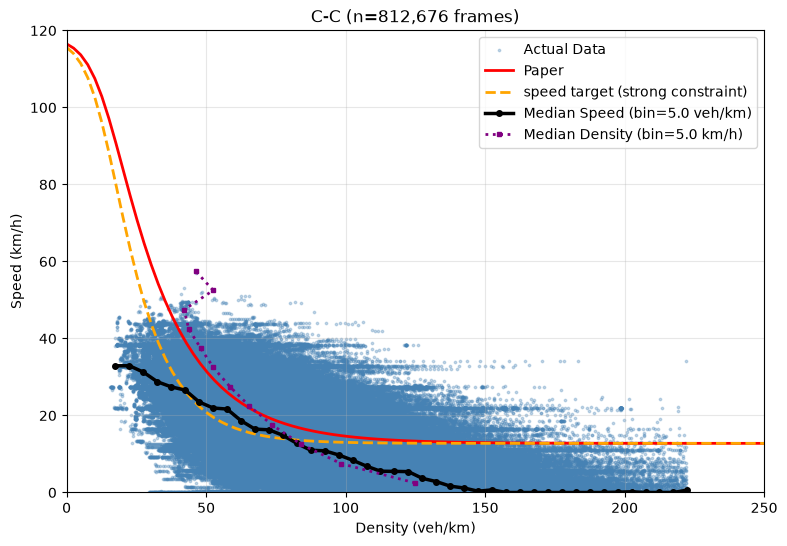

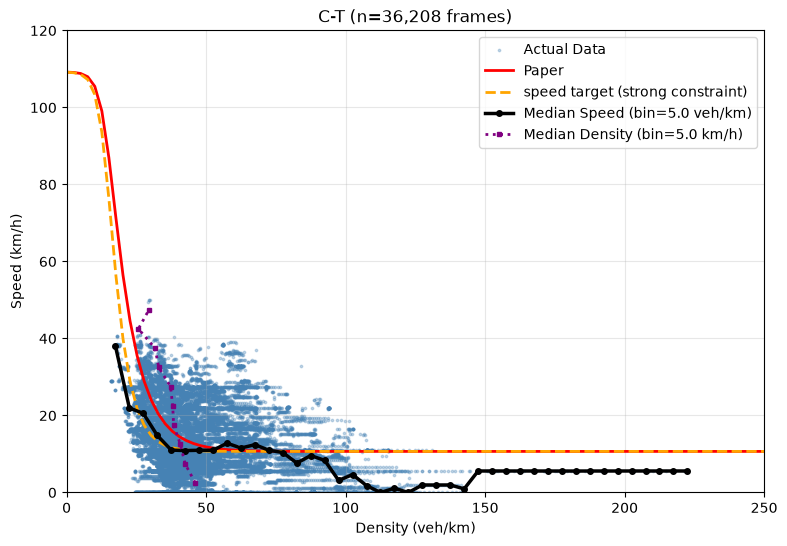

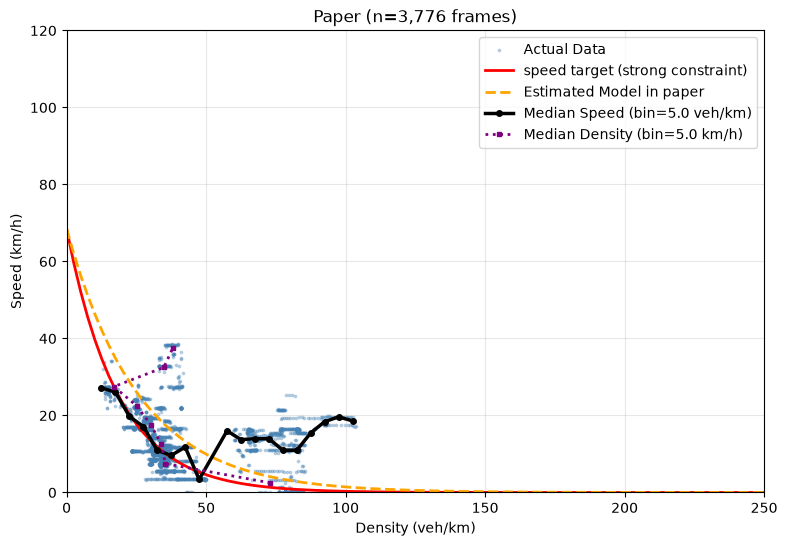

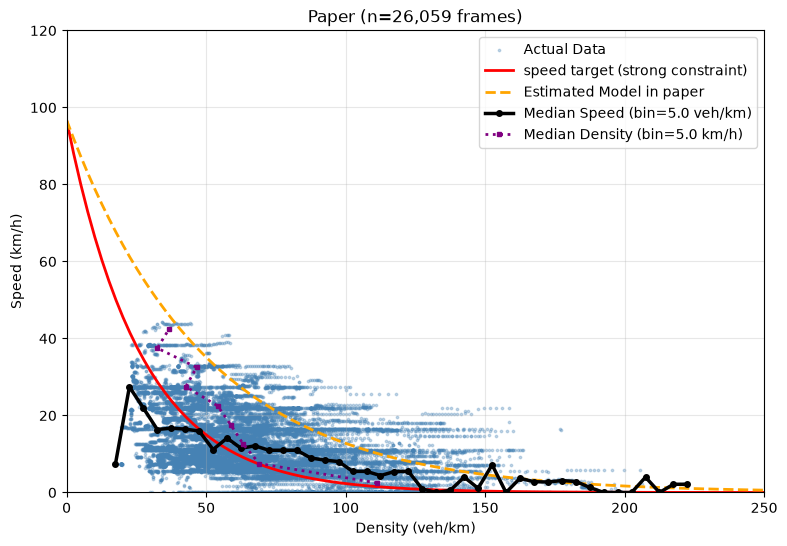

In [96]:
#名目速度関数の推定
df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_mdensity = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

#c-cペア
#ほとんど論文値を与えた場合(theta2だけをフィッティング)
result_cc_strong_constraint = fit_nominal_speed_logistic(
    df_mdensity, mode_id=1,
    lower_bounds=[12.76, 118.36, 12.67, 4.99, 0.001],
    upper_bounds=[12.77, 118.37, 12.68, 5.00, 100.0], 
    init_params = [12.762, 118.367, 12.676, 4.995, 0.5]
)

#c-tペア
result_ct_strong_constraint = fit_nominal_speed_logistic(
    df_mdensity, mode_id=2,
    lower_bounds=[10.665, 109.222, 14.119, 2.160, 0.001],
    upper_bounds=[10.675, 109.232, 14.129, 2.170, 100.0], 
    init_params = [10.670, 109.227, 14.124, 2.165, 0.5]
)


#ほとんど論文値を与えた場合(rhocだけをフィッティング)
#t-tペア
result_tt_strong_constraint = fit_nominal_speed_underwood(
    df_mdensity, mode_id=4,
    lower_bounds = [68.473, 1.000],
    upper_bounds = [68.483, 100.000],
    init_params = [68.478, 50.000]
)

#t-cペア
result_tc_strong_constraint = fit_nominal_speed_underwood(
    df_mdensity, mode_id=3,
    lower_bounds = [96.717, 1.000],
    upper_bounds = [96.727, 100.000],
    init_params = [96.722, 50.000]
)

results_cc_paper_km =  {'mode_id': 1, 'ub': 12.762, 'uf': 118.367, 'rhoc': 12.676,
            'theta1': 4.995, 'theta2': 0.2309, 'test_mae': 6.73}
results_ct_paper_km =  {'mode_id': 2, 'ub': 10.670, 'uf': 109.227, 'rhoc': 14.124,
            'theta1': 2.165, 'theta2': 0.2673, 'test_mae': 7.55}

results_tt_paper_km =  {'mode_id': 4, 'uf': 68.478,'rhoc': 25.936, 'test_mae': 3.94}
results_tc_paper_km =  {'mode_id': 3, 'uf': 96.722,'rhoc': 49.393, 'test_mae': 12.57}

# 結果のプロット
plot_model_logistic(df_mdensity, 1,results_cc_paper_km,result_cc_strong_constraint,"C-C","Paper","speed target (strong constraint)")
plot_model_logistic(df_mdensity, 2,results_ct_paper_km,result_ct_strong_constraint,"C-T","Paper","speed target (strong constraint)")

plot_model_underwood(df_mdensity, 4,results_tt_paper_km,result_tt_strong_constraint,"T-T","Paper","speed target (strong constraint)")
plot_model_underwood(df_mdensity, 3,results_tc_paper_km,result_tc_strong_constraint,"T-C","Paper","speed target (strong constraint)")




In [104]:
#スケーリングパラメータの計算
result_a2 = fit_scaling_parameter_logistic(df_mdensity, mode_id=2, nominal_params=result_cc_strong_constraint)
result_b1 = fit_scaling_parameter_underwood(df_mdensity, mode_id=3, nominal_params=result_tt_strong_constraint)

--- mode_id=2 スケーリングパラメータ推定結果 ---
a = 0.4700
テストMAE: 6.789 km/h
--- mode_id=3 スケーリングパラメータ推定結果 ---
b = 1.8331
テストMAE: 6.106 km/h


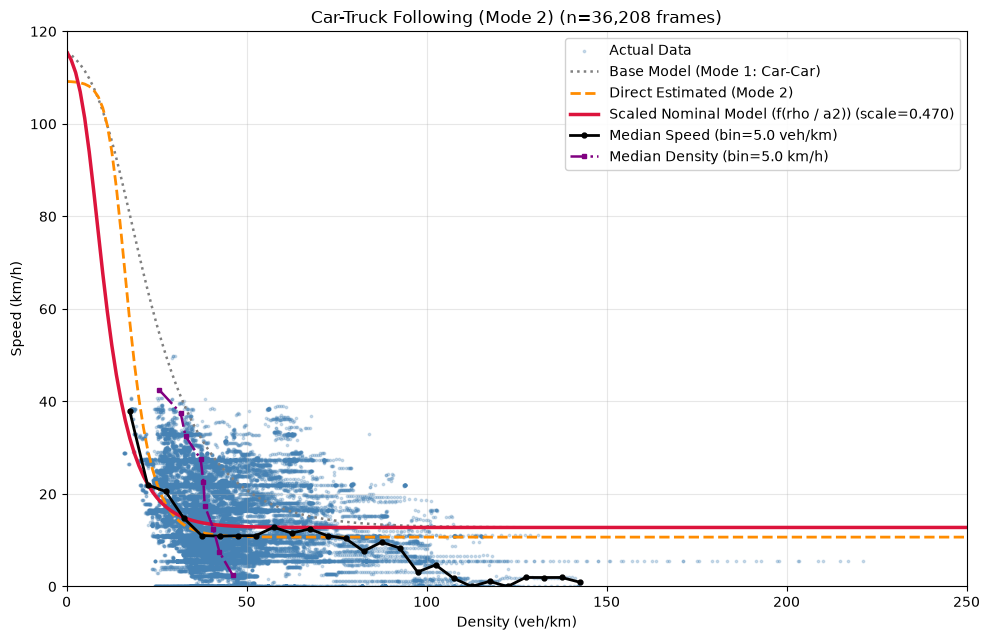

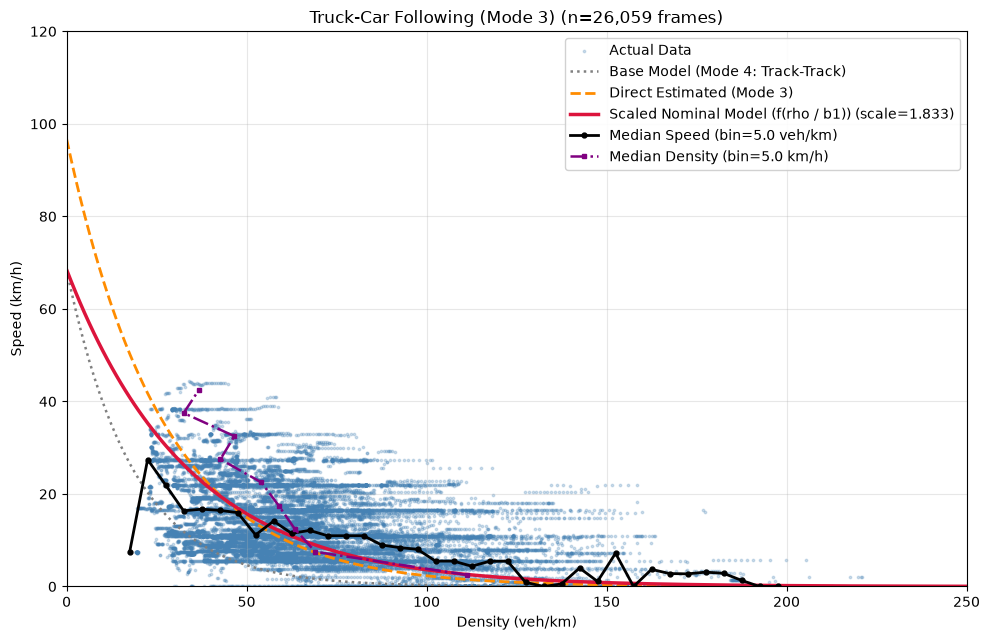

In [108]:
plot_model_logistic_scaling(
    df=df_mdensity,
    mode_id=2,
    base_params=result_cc_strong_constraint,
    direct_params=result_ct_strong_constraint,
    scaling_param=result_a2,
    mode_name="Car-Truck Following (Mode 2)",
    label_base="Base Model (Mode 1: Car-Car)",
    label_direct="Direct Estimated (Mode 2)",
    label_scaled="Scaled Nominal Model (f(rho / a2))",
)

plot_model_underwood_scaling(
    df=df_mdensity,
    mode_id=3,
    base_params=result_tt_strong_constraint,
    direct_params=result_tc_strong_constraint,
    scaling_param=result_b1,
    mode_name="Truck-Car Following (Mode 3)",
    label_base="Base Model (Mode 4: Track-Track)",
    label_direct="Direct Estimated (Mode 3)",
    label_scaled="Scaled Nominal Model (f(rho / b1))",
)

### 異常な密度(車頭距離)を除外<br>
名目速度関数の推定では異常な密度をもつデータは除外する。<br>
マクロ密度を考える際には問題はないため、それ以降は推定時では除外したデータも推定された名目速度関数に従うと仮定して進める。<br>

車体が少なくとも4mあるとして、15feet=約4.5m　をとりあえずの閾値に設定<br>
<small>8/31 :以前入れていた平滑化は操作を複雑にするだけなので削除した。</small>


In [8]:
#密度を確認
FT_TO_M = 0.3048 #フィートにこれをかけたらメートルになる。　


# まず異常値の実態を確認 15feet=4.572mくらい
print("Space_Headway <= 0feet の行数:", (df_final['Space_Headway'] <= 0).sum())
print("Space_Headway <= 14feeet の行数:", (df_final['Space_Headway'] <= 10).sum())
print("Space_Headway <= 15feeet の行数:", (df_final['Space_Headway'] <= 15).sum())
print("Space_Headway(feet)の分布:")
print(df_final['Space_Headway'].describe())
print("\n下位1%の値:", df_final['Space_Headway'].quantile(0.01), "feet")

Space_Headway <= 0feet の行数: 0
Space_Headway <= 14feeet の行数: 578
Space_Headway <= 15feeet の行数: 3038
Space_Headway(feet)の分布:
count    881448.000000
mean         44.184143
std          19.711092
min           0.310000
25%          30.350000
50%          39.810000
75%          52.770000
max         250.990000
Name: Space_Headway, dtype: float64

下位1%の値: 17.45 feet


In [ ]:

def filter_invalid_headway(df, min_spacing_m=4.5, ft_to_m=0.3048):
    """
    Space_Headway(ft)に基づいて異常な小車間距離データをフィルタリングする関数
    """
    min_spacing_ft = min_spacing_m / ft_to_m
    df_filtered = df.copy()

    before = len(df_filtered)

    # フィルタリング条件: Space_Headway > min_spacing_ft の行だけを残す
    df_filtered = df_filtered[df_filtered['Space_Headway'] > min_spacing_ft]
    after = len(df_filtered)

    print("\n--閾値以下の車頭距離データを除外--")
    print(f"spacing <= {min_spacing_m}m ({min_spacing_ft:.2f}ft) の行を除外: {before:,} -> {after:,} (除外 {before-after:,}行)")

    
    return df_filtered


def compute_micro_density(df, ft_to_m=0.3048):
    """
    車間距離(ft)からミクロ密度を算出する関数
    """
    df_computed = df.copy()

    # 1000m / (Space_Headway * ft_to_m)
    #ミクロ密度は車頭距離の逆数　単位もveh/kmにここで変換しておく
    df_computed['mdensity_veh_km'] = 1000 / (df_computed['Space_Headway'] * ft_to_m)
    print("\n--ミクロ密度を計算--")
    return df_computed



--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)


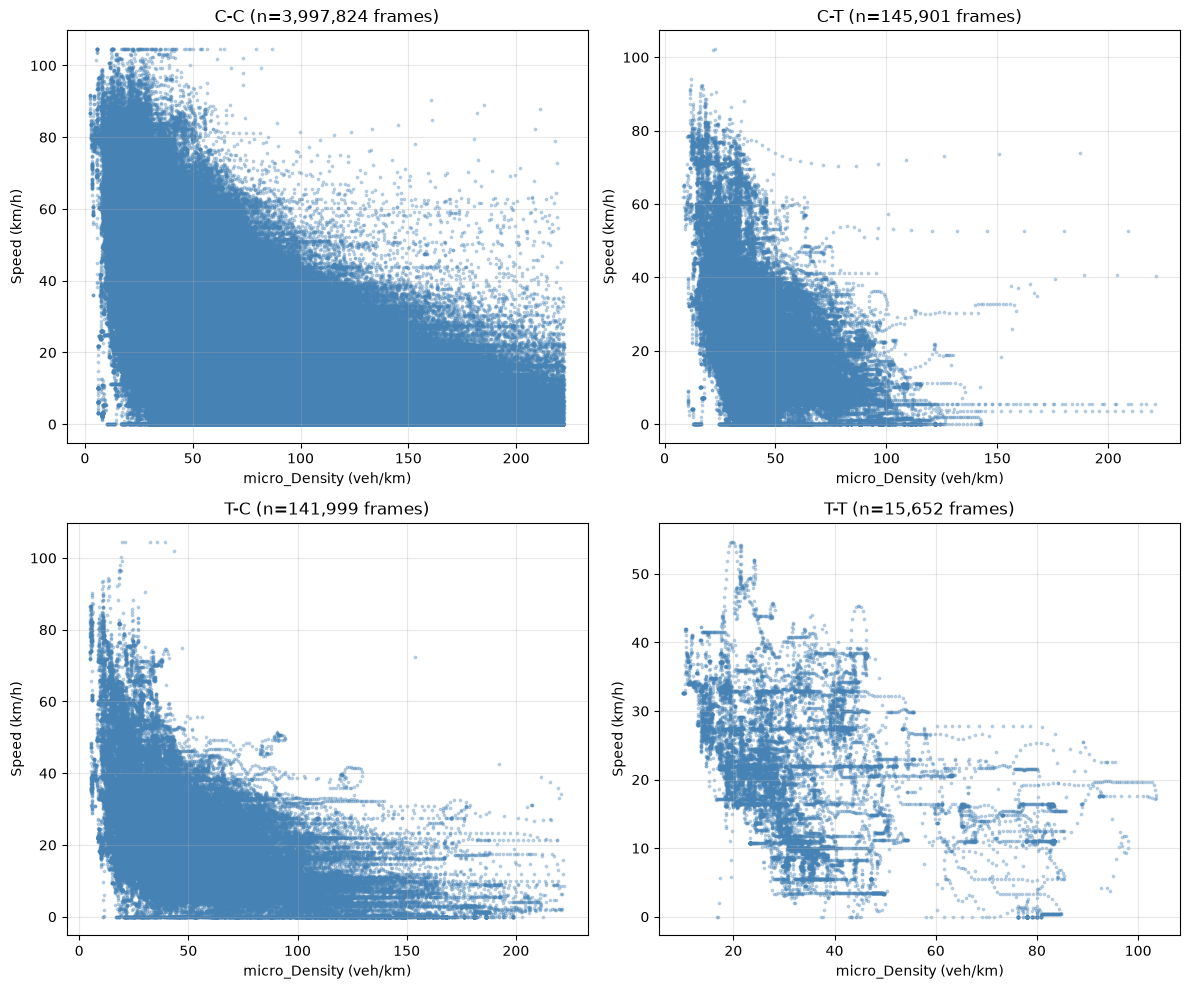

In [ ]:
# df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# df_mdensity = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)
# plot_density_speed_by_mode(df_mdensity)

#全車線データ
df_filtered = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_mdensity = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)
plot_density_speed_by_mode(df_mdensity)

#laneID=1のデータだけ
# df_filtered = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# df_lane1 = df_filtered[df_filtered['Lane_ID'] == 1].copy()
# df_mdensity_lane1 = compute_micro_density(df_lane1, ft_to_m=FT_TO_M)
# plot_density_speed_by_mode(df_mdensity_lane1)


### マクロ密度・平均速度の計算

In [54]:
#　スナップショットからの密度、平均速度を計算する。
# 密度は"車種ごと"に計算。

def compute_macroscopic_data(df, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5,
                                    L_m=None, n_lanes=None, frame_interval_ms=100):
    """
    一定間隔(デフォルト5フレーム=0.5秒)でスナップショットを取り、
    マクロ密度(veh/km/lane)・平均速度(km/h)・流率(veh/h/lane)を計算する。

    df: trajectoryデータ(関数内でlanes/classesに絞る前のデータでも可)
    lanes: 対象車線
    classes: 対象車種(2=car, 3=truck)
    snapshot_step_frames: 何フレームおきにスナップショットを取るか(デフォルトは5フレーム(論文値))
    L_m: 実際のデータのy座標の範囲から自動計算する 
    n_lanes: 車線数(デフォルトは3)
    """
    #snaphshot間隔を時間に直す
    step_ms = frame_interval_ms * snapshot_step_frames  # 500ms

    # time_periodごとに、スナップショットを撮る時刻の集合を作成 
    valid_times = set()
    #time_periodごとにグループ分けし１ブロックずつループ処理
    for tp, group in df.groupby('time_period'):
        # 観測時間の最小値(t_min)・最大値(t_max)を取得
        t_min = int(group['Global_Time'].min())
        t_max = int(group['Global_Time'].max())
        
        # t_min始まりの0.5秒(500ms)ごとの時刻配列を作成し、集合に追加
        snapshot_times_tp = set(range(t_min, t_max + 1, step_ms))
        #上で作った集合に追加し、全時間区間のスナップショットを撮る時間リストを作成（globaltimeは重複しないためデータの重複もないはず）
        valid_times.update(snapshot_times_tp)

    # データを車線と車種で絞り込む
    target = df[df['Lane_ID'].isin(lanes) & df['v_Class'].isin(classes)].copy()

    #車線の長さ・車線数
    #L_mが引数で与えられなかった場合、ｙ座標の最大値と最小値の差から計算
    if L_m is None:
        L_m = (target['Local_Y'].max() - target['Local_Y'].min()) * FT_TO_M
        
    #n_lanesが引数で与えられなかった場合、laneの数を計算
    if n_lanes is None:
        n_lanes = len(lanes)

    L_km = L_m / 1000

    print(f"区間長: {L_m:.1f} m, 車線数: {n_lanes}")

    # gloobaltimeが以前作ったスナップショットを撮る時間リストに入っている行を抽出
    snap_rows = target[target['Global_Time'].isin(valid_times)]

    #抽出したスナップショットを撮るデータを時間と車種でグループ化し、グループごとに集計処理
    agg = snap_rows.groupby(['time_period', 'Global_Time', 'v_Class']).agg(
        n_vehicles=('Vehicle_ID', 'size'),#車種ごとの車両数　Vehicle_ID 列のデータ行数（size）を数えて、n_vehicles（車両数）という列名で保存
        speed_kmh=('v_Vel', lambda s: (s * FT_TO_M * 3.6).mean())
        #平均速度　feet/s -> m/s -> km/h　v_Vel 列を単位換算して平均値（mean）を計算し、speed_kmh（平均速度）という列名で保存　
    ).reset_index()

    agg['density_veh_km'] = agg['n_vehicles'] / (L_km * n_lanes)#マクロ密度の計算　面積で車両数を割る
    agg['flow_veh_h'] = agg['density_veh_km'] * agg['speed_kmh']#流量の計算　
    print("\n--マクロ密度・平均速度を計算--")

    return agg

#マクロ密度は、ミクロ密度がおかしくても問題ないため以上車間距離除外前データを使用
df_macro_data = compute_macroscopic_data(df, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)

df_macro_data.head()


区間長: 545.8 m, 車線数: 3

--マクロ密度・平均速度を計算--


,time_period,Global_Time,v_Class,n_vehicles,speed_kmh,density_veh_km,flow_veh_h
0,1,1113433135300,3,1,12.157862,0.610694,7.424735
1,1,1113433135800,3,1,12.157862,0.610694,7.424735
2,1,1113433136300,2,1,13.716000,0.610694,8.376280
3,1,1113433136300,3,1,13.661136,0.610694,8.342775
4,1,1113433136800,2,1,13.737946,0.610694,8.389682


### 基本図を描く

区間長: 513.0 m, 車線数: 3


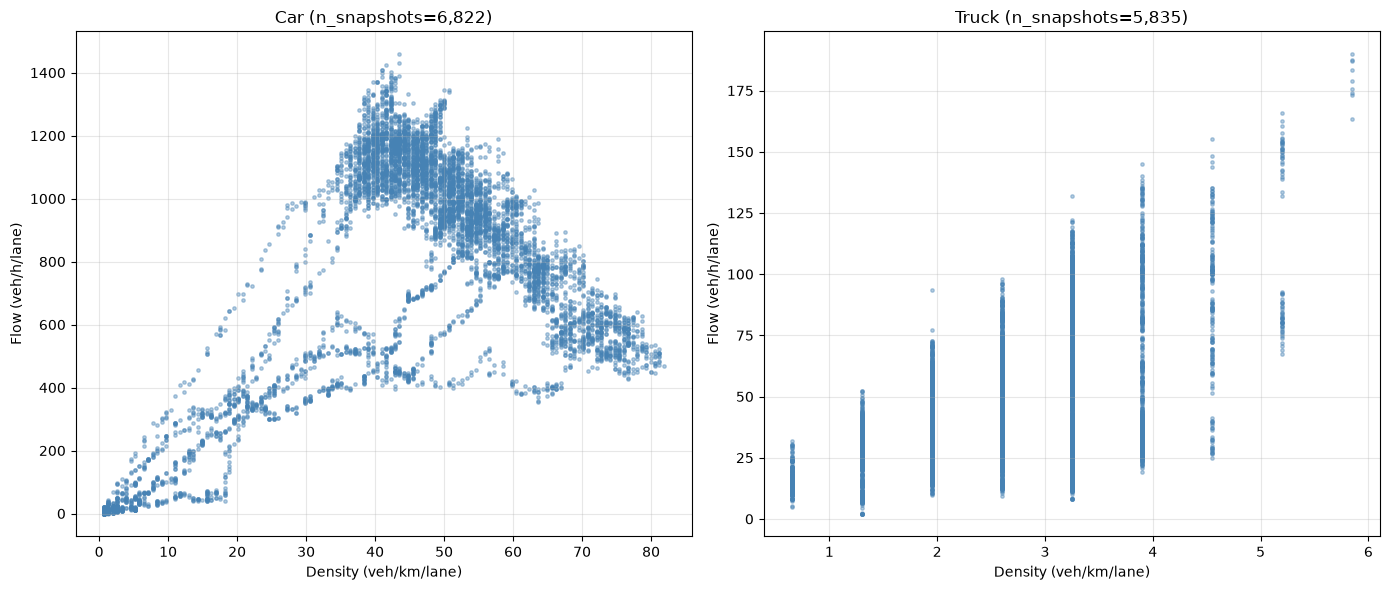

In [26]:
#フィルタリング前データ
#snapshots = compute_macroscopic_data(df_clean, lanes=(2,3,4), classes=(2, 3), snapshot_step_frames=5)
#フィルタリング後データ
snapshots = compute_macroscopic_data(df_mdensity, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)

class_labels = {2: 'Car', 3: 'Truck'}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cls in zip(axes, [2, 3]):
    sub = snapshots[snapshots['v_Class'] == cls]
    ax.scatter(sub['density_veh_km'], sub['flow_veh_h'], s=6, alpha=0.4, color='steelblue')
    ax.set_xlabel('Density (veh/km/lane)')
    ax.set_ylabel('Flow (veh/h/lane)')
    ax.set_title(f'{class_labels[cls]} (n_snapshots={len(sub):,})')
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

区間長: 472.7 m, 車線数: 3


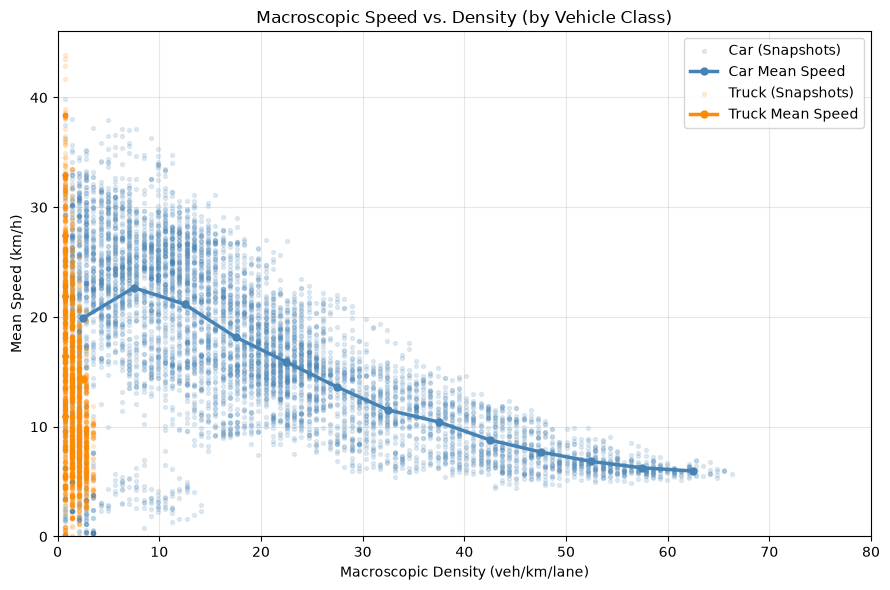

In [38]:
#マクロ密度は、ミクロ密度がおかしくても問題ないため除外前データを使用
df_macro_density = compute_macroscopic_data(df_final, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)
plot_macroscopic_speed_density(
    df_macro_density, bin_width=5.0, max_density=80
)

### 乗用車クラス　パラメータ推定

#### 推定関数

In [58]:
def logistic_speed_density(rho, ub, uf, rhoc, theta1, theta2):
    """
    論文Eq(17)のロジスティック速度-密度モデル。
    f(rho) = ub + (uf - ub) / (1 + exp((rho-rhoc)/theta1))^theta2
    """
    exp_term = np.exp(np.clip((rho - rhoc) / theta1, -100, 100))  # expの中が大きくなるとすぐにオーバーフローするため防止策を入れておく
    return ub + (uf - ub) / ((1 + exp_term) ** theta2)


def fit_nominal_speed_logistic(df, mode_id, density_col='mdensity_veh_km', speed_col='v_Vel',
                                 lower_bounds=None, upper_bounds=None, init_params=None,
                                 max_eval=15000, test_size=0.3, random_state=42):
    """
    指定した追従タイプ(mode_id)のデータから、
    ロジスティックモデルのパラメータ(ub, uf, rhoc, theta1, theta2)を
    ISRES(改良型確率的ランキング進化戦略)で推定する。

    パラメータの並び順: [ub, uf, rhoc, theta1, theta2]
    - ub: 平均走行速度(km/h)     - uf: 自由流速度(km/h)
    - rhoc: 臨界密度(veh/km)     - theta1: 曲線の伸び(密度と同じ単位)
    - theta2: 曲線の歪み(無次元)

    lower_bounds/upper_bounds/init_paramsを渡せば探索範囲・初期値に制約を与える。
    """
    
    # 対象の追従タイプ(mode_id)に絞り、欠損を除く
    data = df[df['mode_id'] == mode_id].dropna(subset=[density_col, speed_col]).copy()
    if len(data) == 0:
        raise ValueError(f"mode_id={mode_id} に該当するデータがありません。")

    #速度をft/s -> km/hに変換(密度は既にveh/km前提 compute_micro_densityで計算済み)　
    data['speed_kmh'] = data[speed_col] * 0.3048 * 3.6

    X = data[density_col].values   # 密度(veh/km)
    Y = data['speed_kmh'].values   # 速度(km/h)

    #7:3で学習・評価データに分割(論文と同じ比率)
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    #目的関数：学習データに対するL1誤差の合計(論文のl(theta)の定義通り)　gradは勾配情報だがISRESは使用しない
    #xはアルゴリズムが試行する5つのパラメータのリスト
    def objective(x, grad):
        ub, uf, rhoc, theta1, theta2 = x
        if uf <= ub:  # 自由流速度が平均速度より遅い、という物理的にありえない組合せは弾く
            return 1e10 #巨大な誤差値を返す
        pred = logistic_speed_density(X_train, ub, uf, rhoc, theta1, theta2)#予測速度を計算
        return np.sum(np.abs(Y_train - pred))#誤差の絶対値の足し合わせを求める

    #探索範囲・初期値のデフォルト(指定があれば上書き)
    if lower_bounds is None:
        lower_bounds = [0.0, 20.0, 5.0, 0.5, 0.05]     # [ub, uf, rhoc, theta1, theta2]
    if upper_bounds is None:
        upper_bounds = [60.0, 130.0, 150.0, 30.0, 3.0]
    if init_params is None:
        init_params = [15.0, 80.0, 30.0, 10.0, 1.0]

    #ISRES(GN_ISRES)で最適化
    #GN_ISRES,GN_DIRECT,LN_COBYLA,LD_MMA　等別手法
    opt = nlopt.opt(nlopt.GN_ISRES, 5)
    opt.set_lower_bounds(lower_bounds)
    opt.set_upper_bounds(upper_bounds)
    opt.set_min_objective(objective)#objectiveを最小化する
    opt.set_maxeval(max_eval)#打ち切りの上限
    best_params = opt.optimize(init_params)#初期値リストの値からスタートして探索を実行

    #テストデータでMAEを評価　絶対平均誤差
    ub, uf, rhoc, theta1, theta2 = best_params
    Y_pred_test = logistic_speed_density(X_test, ub, uf, rhoc, theta1, theta2)
    test_mae = mean_absolute_error(Y_test, Y_pred_test)

    print(f"\n--mode_id={mode_id}の名目速度関数paramを推定--")
    print(f"--- mode_id={mode_id} 推定結果 ---")
    print(f"ub={ub:.3f} km/h, uf={uf:.3f} km/h, rhoc={rhoc:.3f} veh/km, "
          f"theta1={theta1:.3f}, theta2={theta2:.3f}")
    print(f"テストMAE: {test_mae:.3f} km/h")

    return {'mode_id': mode_id, 'ub': ub, 'uf': uf, 'rhoc': rhoc,
            'theta1': theta1, 'theta2': theta2, 'test_mae': test_mae}

In [63]:
#ロジスティックモデルを逆関数にして、速度から密度を予測する関数を定義
def logistic_density_speed(v, ub, uf, rhoc, theta1, theta2):
    """
    逆関数: 速度 v から 密度 rho を予測
    rho = rhoc + theta1 * ln( ((uf - ub) / (v - ub))^(1/theta2) - 1 )
    """
    # 数学的に定義できない領域（v <= ub または v >= uf）に対する数値的クリップ
    #0で割り算することを防ぐ
    eps = 1e-4
    v_clipped = np.clip(v, ub + eps, uf - eps)

    # 累乗項の計算
    ratio = (uf - ub) / (v_clipped - ub)
    inner_term = (ratio ** (1.0 / theta2)) - 1.0

    # 対数の中身が 0 以下にならないようにクリップ
    inner_term = np.clip(inner_term, 1e-10, None)

    return rhoc + theta1 * np.log(inner_term)


def fit_nominal_density_logistic(
    df,
    mode_id,
    density_col='mdensity_veh_km',
    speed_col='v_Vel',
    lower_bounds=None,
    upper_bounds=None,
    init_params=None,
    max_eval=15000,
    test_size=0.3,
    random_state=42,
):
    """速度を入力として密度を予測し、密度の誤差(L1 Loss)を最小化する最適化関数"""
    # データの抽出
    data = (
        df[df['mode_id'] == mode_id]
        .dropna(subset=[density_col, speed_col])
        .copy()
    )

    if len(data) == 0:
        raise ValueError(f'mode_id={mode_id} に該当するデータがありません。')

    # 速度を ft/s -> km/h に変換
    data['speed_kmh'] = data[speed_col] * 0.3048 * 3.6

    X = data['speed_kmh'].values  # 入力: 速度 (km/h)
    Y = data[density_col].values  # ターゲット: 密度 (veh/km)

    #学習・評価データに分割
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    # 目的関数：密度のL1誤差の合計
    def objective(x, grad):
        ub, uf, rhoc, theta1, theta2 = x

        # 物理的な制約違反に対するペナルティ
        if uf <= ub:
            return 1e10

        # 速度 X_train から 密度 pred_rho を予測
        pred_rho = logistic_density_speed(X_train, ub, uf, rhoc, theta1, theta2)

        # 実測密度 Y_train との絶対誤差の合計
        return np.sum(np.abs(Y_train - pred_rho))

    # 探索範囲・初期値の設定
    if lower_bounds is None:
        lower_bounds = [0.0, 20.0, 5.0, 0.5, 0.05]
    if upper_bounds is None:
        upper_bounds = [60.0, 130.0, 150.0, 100.0, 100.0]
    if init_params is None:
        init_params = [15.0, 120.0, 30.0, 10.0, 1.0]

    # Boundsの範囲外エラー(invalid_argument)防止用クランプ
    init_params = np.clip(init_params, lower_bounds, upper_bounds).tolist()

    # ISRESによる最適化
    opt = nlopt.opt(nlopt.GN_ISRES, 5)
    opt.set_lower_bounds(lower_bounds)
    opt.set_upper_bounds(upper_bounds)
    opt.set_min_objective(objective)
    opt.set_maxeval(max_eval)
    best_params = opt.optimize(init_params)

    # ⑦ テストデータで密度のMAEを評価
    ub, uf, rhoc, theta1, theta2 = best_params
    Y_pred_test = logistic_density_speed(
        X_test, ub, uf, rhoc, theta1, theta2
    )
    test_mae_density = mean_absolute_error(Y_test, Y_pred_test)

    # （参考）予測した密度から算出した速度でのMAEも計算
    v_pred_test = logistic_speed_density(
        Y_test, ub, uf, rhoc, theta1, theta2
    )
    test_mae_speed = mean_absolute_error(X_test, v_pred_test)

    print(f'--- mode_id={mode_id} 密度ターゲットでの推定結果 ---')
    print(
        f'ub={ub:.3f} km/h, uf={uf:.3f} km/h, rhoc={rhoc:.3f} veh/km, '
        f'theta1={theta1:.3f}, theta2={theta2:.3f}'
    )
    print(f'テスト密度 MAE: {test_mae_density:.3f} veh/km')
    print(f'テスト速度 MAE: {test_mae_speed:.3f} km/h')

    return {
        'mode_id': mode_id,
        'ub': ub,
        'uf': uf,
        'rhoc': rhoc,
        'theta1': theta1,
        'theta2': theta2,
        'test_mae_density': test_mae_density,
        'test_mae_speed': test_mae_speed,
    }

#### C-C追従

In [ ]:
#データの用意
df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_mdensity = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)


#論文値（単位はkm）
results_cc_paper_km =  {'mode_id': 1, 'ub': 12.762, 'uf': 118.367, 'rhoc': 12.676,
            'theta1': 4.995, 'theta2': 0.2309, 'test_mae': 6.73}

#パラメータを推定
#result_cc = fit_nominal_speed_logistic(df_filtered, mode_id=1)
#制約なしの場合
result_cc_no_constraint = fit_nominal_speed_logistic(
    df_mdensity, mode_id=1,
)

# 比較的弱い制約を入れた場合
# result_cc_week_constraint = fit_nominal_speed_logistic(
#     df_mdensity, mode_id=1,
#     lower_bounds=[10.0, 110.0, 10.0, 0.5, 0.05],
#     upper_bounds=[20.0, 130.0, 50.0, 100.0, 100.0], 
#     init_params = [15.0, 120.0, 30.0, 10.0, 1.0]
# )

#ほとんど論文値を与えた場合(theta2だけをフィッティング)
result_cc_strong_constraint = fit_nominal_speed_logistic(
    df_mdensity, mode_id=1,
    lower_bounds=[12.76, 118.36, 12.67, 4.99, 0.001],
    upper_bounds=[12.77, 118.37, 12.68, 5.00, 100.0], 
    init_params = [12.762, 118.367, 12.676, 4.995, 0.5]
)


#laneID=1のデータだけ
df_filtered = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_lane1 = df_filtered[df_filtered['Lane_ID'] == 1].copy()
df_mdensity_lane1 = compute_micro_density(df_lane1, ft_to_m=FT_TO_M)
result_cc_no_constraint_lane1 = fit_nominal_speed_logistic(
    df_mdensity_lane1, mode_id=1,
)


#全データバージョン results_cc_all = [0.393, 76.986, 5.050, 29.048, 0.607] #ALLでの推定結果
#データ準備
# df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

# result_all = fit_nominal_speed_logistic(df_all, mode_id=1)



--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 881,448 -> 878,719 (除外 2,729行)

--ミクロ密度を計算--

--mode_id=1の名目速度関数paramを推定--
--- mode_id=1 推定結果 ---
ub=0.006 km/h, uf=38.066 km/h, rhoc=68.729 veh/km, theta1=29.723, theta2=1.138
テストMAE: 5.283 km/h


C:\Users\AMhetero\AppData\Local\Temp\ipykernel_44756\2671650145.py:7: RuntimeWarning: overflow encountered in power
  return ub + (uf - ub) / ((1 + exp_term) ** theta2)



--mode_id=1の名目速度関数paramを推定--
--- mode_id=1 推定結果 ---
ub=12.760 km/h, uf=118.361 km/h, rhoc=12.671 veh/km, theta1=4.993, theta2=0.343
テストMAE: 7.055 km/h


In [62]:
#laneID=1のデータだけ
df_filtered = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_lane1 = df_filtered[df_filtered['Lane_ID'] == 1].copy()
df_mdensity_lane1 = compute_micro_density(df_lane1, ft_to_m=FT_TO_M)
result_cc_no_constraint_lane1 = fit_nominal_speed_logistic(
    df_mdensity_lane1, mode_id=1,
)



--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)

--ミクロ密度を計算--

--mode_id=1の名目速度関数paramを推定--
--- mode_id=1 推定結果 ---
ub=33.941 km/h, uf=111.301 km/h, rhoc=5.260 veh/km, theta1=29.387, theta2=1.270
テストMAE: 8.687 km/h


In [64]:
#速度から密度を推定する。
# df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# df_mdensity = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)


#パラメータを推定
#result_cc = fit_nominal_density_logistic(df_filtered, mode_id=1)
#制約なしの場合
result_cc_no_constraint_density = fit_nominal_density_logistic(
    df_mdensity, mode_id=1,
)

# 比較的弱い制約を入れた場合
# result_cc_week_constraint_density = fit_nominal_density_logistic(
#     df_mdensity, mode_id=1,
#     lower_bounds=[10.0, 110.0, 10.0, 0.5, 0.05],
#     upper_bounds=[20.0, 130.0, 50.0, 100.0, 100.0], 
#     init_params = [15.0, 120.0, 30.0, 10.0, 1.0]
# )

#ほとんど論文値を与えた場合(theta2だけをフィッティング)
result_cc_strong_constraint_density = fit_nominal_density_logistic(
    df_mdensity, mode_id=1,
    lower_bounds=[12.76, 118.36, 12.67, 4.99, 0.001],
    upper_bounds=[12.77, 118.37, 12.68, 5.00, 100.0], 
    init_params = [12.762, 118.367, 12.676, 4.995, 0.5]
)

#laneID=1のデータだけ
df_filtered = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_lane1 = df_filtered[df_filtered['Lane_ID'] == 1].copy()
df_mdensity_lane1 = compute_micro_density(df_lane1, ft_to_m=FT_TO_M)
result_cc_no_constraint_lane1_density = fit_nominal_density_logistic(
    df_mdensity_lane1, mode_id=1,
)


# 全車線データで推定してみる 制約は特になし
# df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
# df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)
# result_density_all = fit_nominal_density_logistic(df_all, mode_id=1)


--- mode_id=1 密度ターゲットでの推定結果 ---
ub=5.044 km/h, uf=51.714 km/h, rhoc=149.078 veh/km, theta1=21.888, theta2=41.852
テスト密度 MAE: 18.244 veh/km
テスト速度 MAE: 6.930 km/h


C:\Users\AMhetero\AppData\Local\Temp\ipykernel_44756\3336620025.py:14: RuntimeWarning: overflow encountered in power
  inner_term = (ratio ** (1.0 / theta2)) - 1.0


--- mode_id=1 密度ターゲットでの推定結果 ---
ub=12.770 km/h, uf=118.367 km/h, rhoc=12.678 veh/km, theta1=4.992, theta2=0.702
テスト密度 MAE: 30.910 veh/km
テスト速度 MAE: 7.833 km/h

--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)

--ミクロ密度を計算--
--- mode_id=1 密度ターゲットでの推定結果 ---
ub=37.967 km/h, uf=107.111 km/h, rhoc=67.337 veh/km, theta1=8.164, theta2=97.217
テスト密度 MAE: 11.448 veh/km
テスト速度 MAE: 14.900 km/h


C:\Users\AMhetero\AppData\Local\Temp\ipykernel_44756\2671650145.py:7: RuntimeWarning: overflow encountered in power
  return ub + (uf - ub) / ((1 + exp_term) ** theta2)


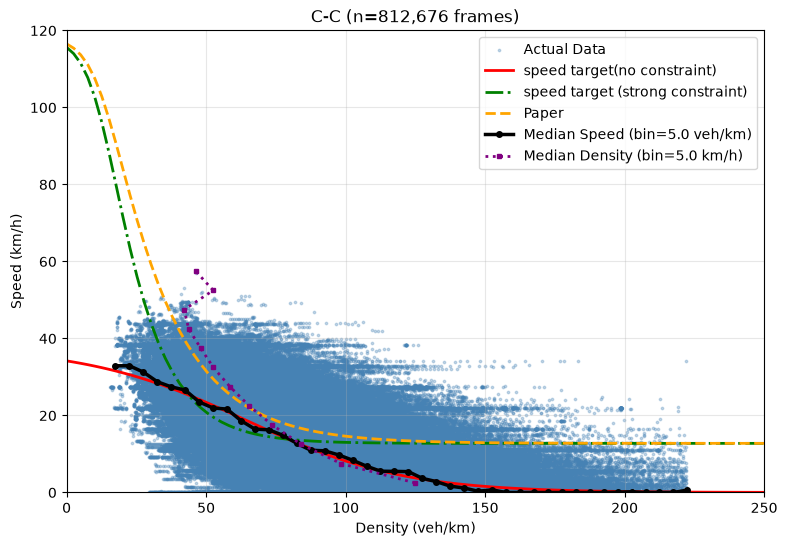

In [ ]:
#speed target ver 結果のプロット
plot_model_logistic_3params(df_mdensity, 1, result_cc_no_constraint,results_cc_paper_km,result_cc_strong_constraint,"C-C","speed target(no constraint)","Paper","speed target (strong constraint)")

#全データと確認
#df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
#df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

#plot_model_logistic(df_all, 1, results_cc_all,results_cc_paper_km,"C-C","Estimated Model(ALL)","Estimated Model in Papaer")
#plot_model_logistic_3params(df_all, 1, results_cc_density_all,results_cc_paper_km,results_density_cc_all_c,"C-C","Density target","Paper","Density (constraint)")


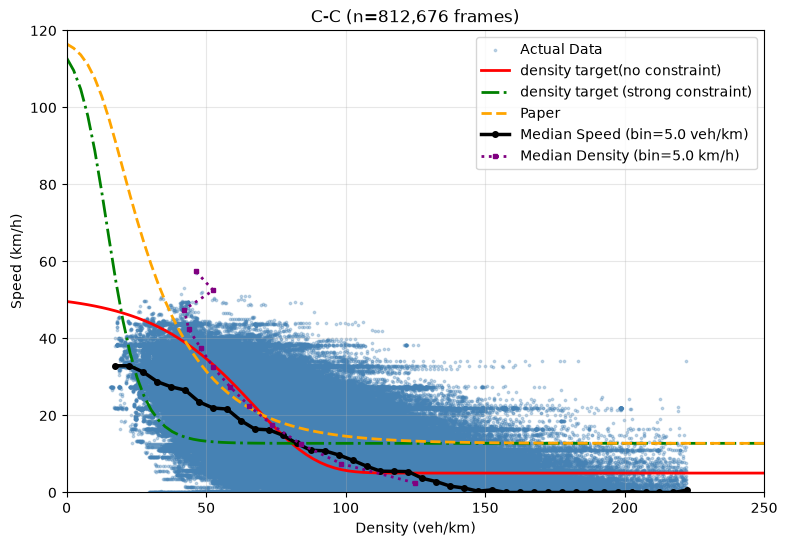

In [69]:
#speed target ver 結果のプロット
plot_model_logistic_3params(df_mdensity, 1, result_cc_no_constraint_density,results_cc_paper_km,result_cc_strong_constraint_density,"C-C","density target(no constraint)","Paper","density target (strong constraint)")

#全データと確認
#df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
#df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

#plot_model_logistic(df_all, 1, results_cc_all,results_cc_paper_km,"C-C","Estimated Model(ALL)","Estimated Model in Papaer")
#plot_model_logistic_3params(df_all, 1, results_cc_density_all,results_cc_paper_km,results_density_cc_all_c,"C-C","Density target","Paper","Density (constraint)")


In [70]:
before = compute_micro_density(filter_invalid_headway(df_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M), ft_to_m=FT_TO_M)
after = df_mdensity  # duration後(df_final相当)

print("duration前の密度分布:")
print(before[before['mode_id']==1]['mdensity_veh_km'].describe())
print("\nduration後の密度分布:")
print(after[after['mode_id']==1]['mdensity_veh_km'].describe())


--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 2,335,438 -> 2,325,263 (除外 10,175行)

--ミクロ密度を計算--
duration前の密度分布:
count    2.119708e+06
mean     7.900524e+01
std      3.267665e+01
min      3.923229e+00
25%      5.535414e+01
50%      7.356143e+01
75%      9.729656e+01
max      2.221286e+02
Name: mdensity_veh_km, dtype: float64

duration後の密度分布:
count    812676.000000
mean         89.781019
std          33.365554
min          15.680542
25%          65.018627
50%          84.557729
75%         109.690401
max         222.128632
Name: mdensity_veh_km, dtype: float64


#### C-T追従

In [65]:
#データの用意
df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_mdensity = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

#論文値（単位はkm）
results_ct_paper_km =  {'mode_id': 2, 'ub': 10.670, 'uf': 109.227, 'rhoc': 14.124,
            'theta1': 2.165, 'theta2': 0.2673, 'test_mae': 7.55}

#パラメータを推定
#result_ct = fit_nominal_speed_logistic(df_filtered, mode_id=2)
#制約なしの場合
result_ct_no_constraint = fit_nominal_speed_logistic(
    df_mdensity, mode_id=2,
)

# 比較的弱い制約を入れた場合
# result_ct_week_constraint = fit_nominal_speed_logistic(
#     df_mdensity, mode_id=2,
#     lower_bounds=[10.0, 110.0, 10.0, 0.5, 0.05],
#     upper_bounds=[20.0, 130.0, 50.0, 100.0, 100.0], 
#     init_params = [15.0, 120.0, 30.0, 10.0, 1.0]
# )

#ほとんど論文値を与えた場合(theta2だけをフィッティング)
result_ct_strong_constraint = fit_nominal_speed_logistic(
    df_mdensity, mode_id=2,
    lower_bounds=[10.665, 109.222, 14.119, 2.160, 0.001],
    upper_bounds=[10.675, 109.232, 14.129, 2.170, 100.0], 
    init_params = [10.670, 109.227, 14.124, 2.165, 0.5]
)


#全データバージョン
#データ準備
# df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

# result_ct_all = fit_nominal_speed_logistic(df_all, mode_id=2)


--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 881,448 -> 878,719 (除外 2,729行)

--ミクロ密度を計算--

--mode_id=2の名目速度関数paramを推定--
--- mode_id=2 推定結果 ---
ub=10.599 km/h, uf=49.849 km/h, rhoc=30.106 veh/km, theta1=8.057, theta2=2.807
テストMAE: 6.486 km/h


C:\Users\AMhetero\AppData\Local\Temp\ipykernel_44756\2671650145.py:7: RuntimeWarning: overflow encountered in power
  return ub + (uf - ub) / ((1 + exp_term) ** theta2)



--mode_id=2の名目速度関数paramを推定--
--- mode_id=2 推定結果 ---
ub=10.674 km/h, uf=109.228 km/h, rhoc=14.120 veh/km, theta1=2.162, theta2=0.423
テストMAE: 6.564 km/h


In [71]:
#速度から密度を推定する方
#データの用意
df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_mdensity = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

#論文値（単位はkm）
results_ct_paper_km =  {'mode_id': 2, 'ub': 10.670, 'uf': 109.227, 'rhoc': 14.124,
            'theta1': 2.165, 'theta2': 0.2673, 'test_mae': 7.55}

#パラメータを推定
#result_ct = fit_nominal_speed_logistic(df_filtered, mode_id=2)
#制約なしの場合
result_ct_no_constraint_density = fit_nominal_density_logistic(
    df_mdensity, mode_id=2,
)

# 比較的弱い制約を入れた場合
# result_ct_week_constraint_density = fit_nominal_density_logistic(
#     df_mdensity, mode_id=2,
#     lower_bounds=[10.0, 110.0, 10.0, 0.5, 0.05],
#     upper_bounds=[20.0, 130.0, 50.0, 100.0, 100.0], 
#     init_params = [15.0, 120.0, 30.0, 10.0, 1.0]
# )

#ほとんど論文値を与えた場合(theta2だけをフィッティング)
result_ct_strong_constraint_density = fit_nominal_density_logistic(
    df_mdensity, mode_id=2,
    lower_bounds=[10.665, 109.222, 14.119, 2.160, 0.001],
    upper_bounds=[10.675, 109.232, 14.129, 2.170, 100.0], 
    init_params = [10.670, 109.227, 14.124, 2.165, 0.5]
)


#全データバージョン
#データ準備
# df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

# result_ct_all_density = fit_nominal_density_logistic(df_all, mode_id=2)


--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 881,448 -> 878,719 (除外 2,729行)

--ミクロ密度を計算--


c:\Users\AMhetero\Documents\研究室\Game_Theory_Algorithm\src\nominal_speed_func.py:226: RuntimeWarning: overflow encountered in power
  """


--- mode_id=2 密度ターゲットでの推定結果 ---
ub=1.986 km/h, uf=40.866 km/h, rhoc=52.819 veh/km, theta1=3.357, theta2=54.773
テスト密度 MAE: 11.666 veh/km
テスト速度 MAE: 12.612 km/h


c:\Users\AMhetero\Documents\研究室\Game_Theory_Algorithm\src\nominal_speed_func.py:9: RuntimeWarning: overflow encountered in power
  import numpy as np


--- mode_id=2 密度ターゲットでの推定結果 ---
ub=10.675 km/h, uf=109.231 km/h, rhoc=14.129 veh/km, theta1=2.160, theta2=0.824
テスト密度 MAE: 18.325 veh/km
テスト速度 MAE: 6.963 km/h


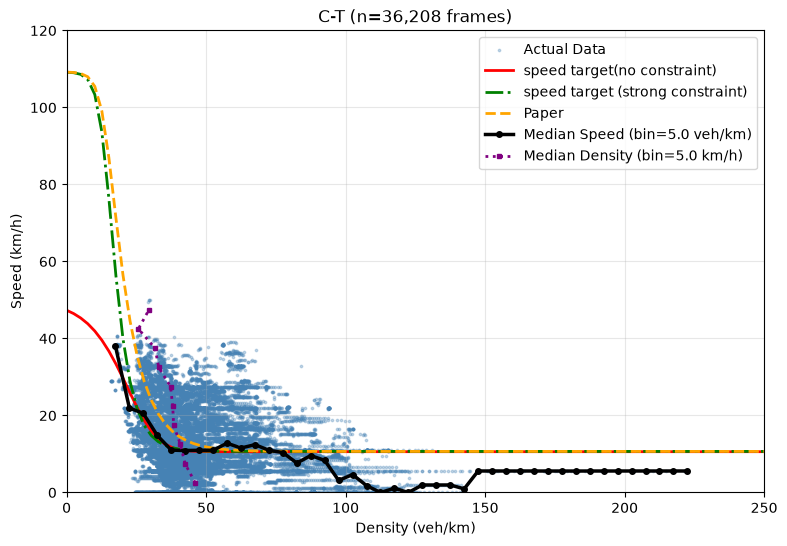

In [72]:
#speed target ver 結果のプロット
plot_model_logistic_3params(df_mdensity, 2, result_ct_no_constraint,results_ct_paper_km,result_ct_strong_constraint,"C-T","speed target(no constraint)","Paper","speed target (strong constraint)")

#全データと確認
#df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
#df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

#plot_model_logistic(df_all, 1, results_cc_all,results_cc_paper_km,"C-C","Estimated Model(ALL)","Estimated Model in Papaer")
#plot_model_logistic_3params(df_all, 1, results_cc_density_all,results_cc_paper_km,results_density_cc_all_c,"C-C","Density target","Paper","Density (constraint)")


c:\Users\AMhetero\Documents\研究室\Game_Theory_Algorithm\src\nominal_speed_func.py:226: RuntimeWarning: overflow encountered in power
  """


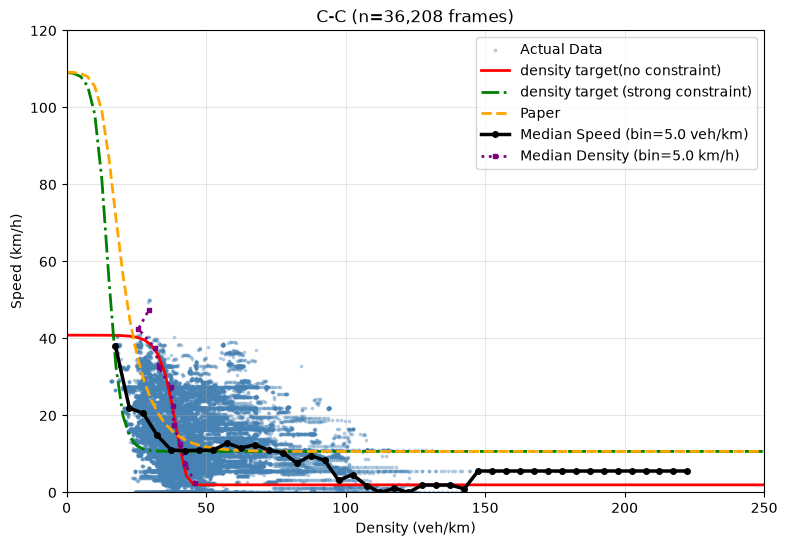

In [73]:
#speed target ver 結果のプロット
plot_model_logistic_3params(df_mdensity, 2, result_ct_no_constraint_density,results_ct_paper_km,result_ct_strong_constraint_density,"C-C","density target(no constraint)","Paper","density target (strong constraint)")

#全データと確認
#df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
#df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

#plot_model_logistic(df_all, 1, results_cc_all,results_cc_paper_km,"C-C","Estimated Model(ALL)","Estimated Model in Papaer")
#plot_model_logistic_3params(df_all, 1, results_cc_density_all,results_cc_paper_km,results_density_cc_all_c,"C-C","Density target","Paper","Density (constraint)")


### トラッククラス　パラメータ推定

#### 推定関数

In [76]:
def underwood_speed_density(rho, uf, rhoc):
    """
    論文Eq(18)のアンダーウッド速度-密度モデル。
    g(rho) = uf * exp(-rho / rhoc)
    """
    return uf * np.exp(np.clip(-rho / rhoc, -100, 100))  # オーバーフロー防止


def fit_nominal_speed_underwood(df, mode_id, density_col='mdensity_veh_km', speed_col='v_Vel',
                                  lower_bounds=None, upper_bounds=None, init_params=None,
                                  max_eval=15000, test_size=0.3, random_state=42):
    """
    指定した追従タイプ(mode_id)のデータから、
    アンダーウッドモデルのパラメータ(uf, rhoc)を
    ISRES(改良型確率的ランキング進化戦略)で推定する。トラッククラス用。

    パラメータの並び順: [uf, rhoc]
    - uf: 自由流速度(km/h)      - rhoc: 臨界密度(veh/km)

    lower_bounds/upper_bounds/init_paramsを渡せば探索範囲・初期値を制約できる。
    """

    # 対象の追従タイプ(mode_id)に絞り、欠損を除く
    data = df[df['mode_id'] == mode_id].dropna(subset=[density_col, speed_col]).copy()
    if len(data) == 0:
        print(f"mode_id={mode_id} に該当するデータがありません。")
        return 0


    #速度をft/s -> km/hに変換(密度は既にveh/km前提)
    data['speed_kmh'] = data[speed_col] * 0.3048 * 3.6

    X = data[density_col].values   # 密度(veh/km)
    Y = data['speed_kmh'].values   # 速度(km/h)

    #70:30で学習・評価データに分割(論文と同じ比率)
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    #目的関数：学習データに対するL1誤差の合計(論文のl(theta)の定義通り) gradはISRESは使用しない
    def objective(x, grad):
        uf, rhoc = x
        pred = underwood_speed_density(X_train, uf, rhoc)
        return np.sum(np.abs(Y_train - pred))#実測値と推測値の差の絶対値の総和

    #探索範囲・初期値のデフォルト(指定があれば上書き)
    #論文の値(km換算): T-T → uf≈68.5, rhoc≈25.9 / T-C → uf≈96.7, rhoc≈49.4
    if lower_bounds is None:
        lower_bounds = [20.0, 5.0]        # [uf, rhoc]
    if upper_bounds is None:
        upper_bounds = [150.0, 100.0]
    if init_params is None:
        init_params = [80.0, 40.0]

    #ISRES(GN_ISRES)で最適化
    opt = nlopt.opt(nlopt.GN_ISRES, 2)
    opt.set_lower_bounds(lower_bounds)
    opt.set_upper_bounds(upper_bounds)
    opt.set_min_objective(objective)
    opt.set_maxeval(max_eval)
    best_params = opt.optimize(init_params)

    #テストデータでMAEを評価 絶対平均誤差
    uf, rhoc = best_params
    Y_pred_test = underwood_speed_density(X_test, uf, rhoc)
    test_mae = mean_absolute_error(Y_test, Y_pred_test)
    
    print(f"\n--mode_id={mode_id}の名目速度関数paramを推定--")
    print(f"--- mode_id={mode_id} 推定結果(アンダーウッド) ---")
    print(f"uf={uf:.3f} km/h, rhoc={rhoc:.3f} veh/km")
    print(f"テストMAE: {test_mae:.3f} km/h")

    return {'mode_id': mode_id, 'uf': uf, 'rhoc': rhoc, 'test_mae': test_mae}

#### T-T追従

In [83]:
#データの用意
df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_mdensity = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)


#論文値（単位はkm）results_tt_paper_km = [68.478, 25.936] #論文値 km/h
results_tt_paper_km =  {'mode_id': 4, 'uf': 68.478,'rhoc': 25.936, 'test_mae': 3.94}

#パラメータを推定
#result_tt = fit_nominal_speed_underwood(df_filtered, mode_id=4)
#制約なしの場合
result_tt_no_constraint = fit_nominal_speed_underwood(
    df_mdensity, mode_id=4,
)

# 比較的弱い制約を入れた場合
# result_tt_week_constraint = fit_nominal_speed_underwood(
#     df_mdensity, mode_id=4,
    # lower_bounds = [63.0, 20.0],
    # upper_bounds = [73.0, 30.0],
    # init_params = [68.0, 25.0]
# )

#ほとんど論文値を与えた場合(rhocだけをフィッティング)
result_tt_strong_constraint = fit_nominal_speed_underwood(
    df_mdensity, mode_id=4,
    lower_bounds = [68.473, 1.000],
    upper_bounds = [68.483, 100.000],
    init_params = [68.478, 50.000]
)


#laneID=1のデータだけ
df_filtered = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_lane1 = df_filtered[df_filtered['Lane_ID'] == 1].copy()
df_mdensity_lane1 = compute_micro_density(df_lane1, ft_to_m=FT_TO_M)
result_tt_no_constraint_lane1 = fit_nominal_speed_underwood(
    df_mdensity_lane1, mode_id=4,
)


#全データバージョン results_tt_all = [30.000, 76.068] #ALLでの推定結果
#データ準備
# df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

# result_all = fit_nominal_speed_underwood(df_all, mode_id=4)


--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 881,448 -> 878,719 (除外 2,729行)

--ミクロ密度を計算--

--mode_id=4の名目速度関数paramを推定--
--- mode_id=4 推定結果(アンダーウッド) ---
uf=20.000 km/h, rhoc=100.000 veh/km
テストMAE: 5.657 km/h

--mode_id=4の名目速度関数paramを推定--
--- mode_id=4 推定結果(アンダーウッド) ---
uf=68.473 km/h, rhoc=18.542 veh/km
テストMAE: 5.862 km/h

--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)

--ミクロ密度を計算--
mode_id=4 に該当するデータがありません。


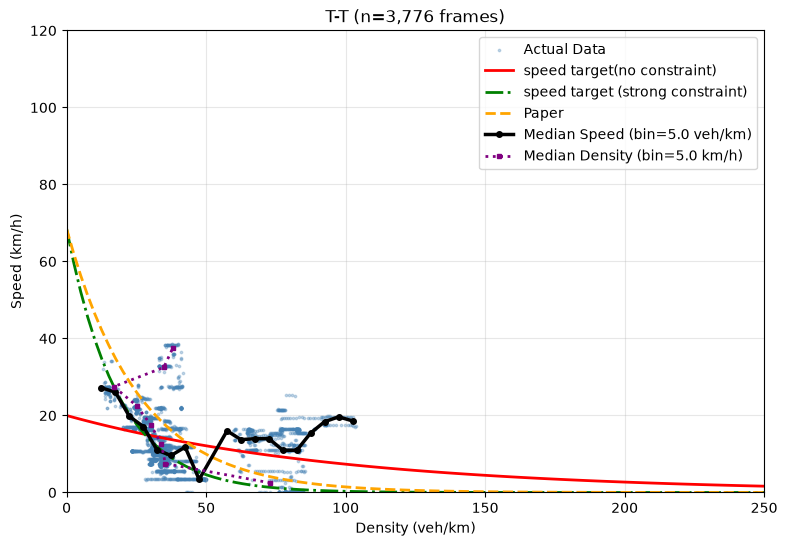

In [93]:
#speed target ver 結果のプロット
plot_model_underwood_3params(df_mdensity, 4, result_tt_no_constraint,results_tt_paper_km,result_tt_strong_constraint,"T-T","speed target(no constraint)","Paper","speed target (strong constraint)")

#全データと確認
#df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
#df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

#plot_model_underwood(df_all, 4, results_tt_all,results_tt_paper_km,"T-T","Estimated Model(ALL)","Estimated Model in Papaer")
#plot_model_underwoood(df_all, 4, results_tt_density_all,results_tt_paper_km,results_density_tt_all_c,"T-T","Density target","Paper","Density (constraint)")


#### T-C追従

In [87]:
#データの用意
df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_mdensity = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)


#論文値（単位はkm）results_tc_paper_km = [96.722, 49.393] #論文値 km/h
results_tc_paper_km =  {'mode_id': 3, 'uf': 96.722,'rhoc': 49.393, 'test_mae': 12.57}

#パラメータを推定
#result_tc = fit_nominal_speed_underwood(df_filtered, mode_id=3)
#制約なしの場合
result_tc_no_constraint = fit_nominal_speed_underwood(
    df_mdensity, mode_id=3,
)

# 比較的弱い制約を入れた場合
# result_tc_week_constraint = fit_nominal_speed_underwood(
#     df_mdensity, mode_id=3,
    # lower_bounds = [63.0, 20.0],
    # upper_bounds = [73.0, 30.0],
    # init_params = [68.0, 25.0]
# )

#ほとんど論文値を与えた場合(theta2だけをフィッティング)
result_tc_strong_constraint = fit_nominal_speed_underwood(
    df_mdensity, mode_id=3,
    lower_bounds = [96.717, 1.000],
    upper_bounds = [96.727, 100.000],
    init_params = [96.722, 50.000]
)


#laneID=1のデータだけ
df_filtered = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_lane1 = df_filtered[df_filtered['Lane_ID'] == 1].copy()
df_mdensity_lane1 = compute_micro_density(df_lane1, ft_to_m=FT_TO_M)
result_tc_no_constraint_lane1 = fit_nominal_speed_underwood(
    df_mdensity_lane1, mode_id=3,
)


#全データバージョン results_tc_all = [41.376, 66.958] #ALLでの推定結果
#データ準備
# df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

# result_all = fit_nominal_speed_underwood(df_all, mode_id=3)


--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 881,448 -> 878,719 (除外 2,729行)

--ミクロ密度を計算--

--mode_id=3の名目速度関数paramを推定--
--- mode_id=3 推定結果(アンダーウッド) ---
uf=30.413 km/h, rhoc=67.335 veh/km
テストMAE: 5.424 km/h

--mode_id=3の名目速度関数paramを推定--
--- mode_id=3 推定結果(アンダーウッド) ---
uf=96.717 km/h, rhoc=26.806 veh/km
テストMAE: 6.717 km/h

--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)

--ミクロ密度を計算--

--mode_id=3の名目速度関数paramを推定--
--- mode_id=3 推定結果(アンダーウッド) ---
uf=64.207 km/h, rhoc=94.788 veh/km
テストMAE: 8.784 km/h


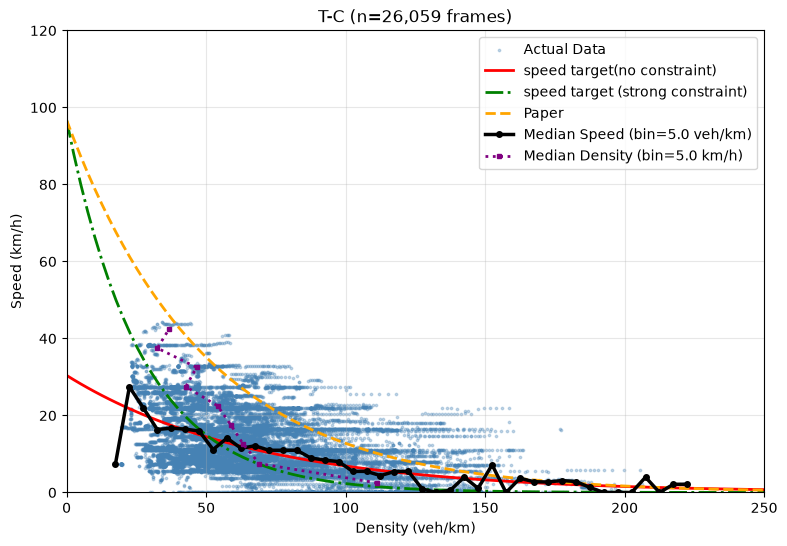

In [91]:
#speed target ver 結果のプロット
plot_model_underwood_3params(df_mdensity, 3, result_tc_no_constraint,results_tc_paper_km,result_tc_strong_constraint,"T-C","speed target(no constraint)","Paper","speed target (strong constraint)")

#全データと確認
#df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
#df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

#plot_model_underwood(df_all, 3, results_tc_all,results_tc_paper_km,"T-C","Estimated Model(ALL)","Estimated Model in Papaer")
#plot_model_underwood(df_all, 3, results_tc_density_all,results_tc_paper_km,results_density_tc_all_c,"T-C","Density target","Paper","Density (constraint)")


### スケーリングパラメータの推定

#### C-T 用

In [97]:
def fit_scaling_parameter_logistic(df, mode_id, nominal_params,
                                     density_col='mdensity_veh_km', speed_col='v_Vel',
                                     lower_bound=0.1, upper_bound=5.0, init_param=1.0,
                                     max_eval=15000, test_size=0.3, random_state=42):
    """
    推定済みの名目速度関数f(=f11)を基準に、
    スケーリングパラメータ a2 を ISRES で推定する。
    論文Eq(20): f12(rho) = f(rho / a2)

    nominal_params: Step 1(a)で推定したロジスティックのパラメータ
                    (fit_nominal_speed_logistic の戻り値をそのまま渡す)
    lower_bound/upper_bound/init_param: スケーリングパラメータの探索範囲・初期値
    """
    #対象の追従タイプ(mode_id)に絞り、欠損を除く
    data = df[df['mode_id'] == mode_id].dropna(subset=[density_col, speed_col]).copy()
    if len(data) == 0:
        raise ValueError(f"mode_id={mode_id} に該当するデータがありません。")

    #速度をft/s -> km/hに変換(密度は既にveh/km前提)
    data['speed_kmh'] = data[speed_col] * 0.3048 * 3.6

    X = data[density_col].values   # 密度(veh/km)
    Y = data['speed_kmh'].values   # 速度(km/h)

    #7:3で学習・評価データに分割(論文と同じ比率)
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    #名目速度関数のパラメータを取り出す(これらは固定。推定するのはスケーリングのみ)
    ub = nominal_params['ub']
    uf = nominal_params['uf']
    rhoc = nominal_params['rhoc']
    theta1 = nominal_params['theta1']
    theta2 = nominal_params['theta2']

    #目的関数：密度を a で割ってから名目速度関数に入れ、L1誤差の合計を取る(Eq(20))
    def objective(x, grad):
        a = x[0]
        pred = logistic_speed_density(X_train / a, ub, uf, rhoc, theta1, theta2)#rhoをaで割ったものを入力
        return np.sum(np.abs(Y_train - pred))

    #ISRES(GN_ISRES)で最適化(推定するのはスケーリングパラメータ1つだけ)
    #    論文Table5の実測値: a2 = 0.4528
    opt = nlopt.opt(nlopt.GN_ISRES, 1)
    opt.set_lower_bounds([lower_bound])
    opt.set_upper_bounds([upper_bound])
    opt.set_min_objective(objective)
    opt.set_maxeval(max_eval)
    best_param = opt.optimize([init_param])

    #テストデータでMAEを評価
    a = best_param[0]
    Y_pred_test = logistic_speed_density(X_test / a, ub, uf, rhoc, theta1, theta2)#rhoをaで割ったものを入力
    test_mae = mean_absolute_error(Y_test, Y_pred_test)

    print(f"--- mode_id={mode_id} スケーリングパラメータ推定結果 ---")
    print(f"a = {a:.4f}")
    print(f"テストMAE: {test_mae:.3f} km/h")

    return {'mode_id': mode_id, 'scaling_param': a, 'test_mae': test_mae}


In [99]:
# 実行：C-T追従(mode_id=2)のスケーリングパラメータ a2 を推定
# nominal_paramsには、C-C(mode_id=1)で推定した結果をそのまま渡す
result_a2 = fit_scaling_parameter_logistic(df_mdensity, mode_id=2, nominal_params=result_cc_strong_constraint)

--- mode_id=2 スケーリングパラメータ推定結果 ---
a = 0.4700
テストMAE: 6.789 km/h


#### T-C用

In [102]:
def fit_scaling_parameter_underwood(df, mode_id, nominal_params,
                                     density_col='mdensity_veh_km', speed_col='v_Vel',
                                     lower_bound=0.1, upper_bound=5.0, init_param=1.0,
                                     max_eval=15000, test_size=0.3, random_state=42):
    """
    推定済みの名目速度関数f(=f22)を基準に、
    スケーリングパラメータ b1 を ISRES で推定する。
    論文Eq(20): f21(rho) = f(rho / b1)

    nominal_params: Step 1(a)で推定したUnderwoodのパラメータ
                    (fit_nominal_speed_underwood の戻り値をそのまま渡す)
    lower_bound/upper_bound/init_param: スケーリングパラメータの探索範囲・初期値
    """
    #対象の追従タイプ(mode_id)に絞り、欠損を除く
    data = df[df['mode_id'] == mode_id].dropna(subset=[density_col, speed_col]).copy()
    if len(data) == 0:
        raise ValueError(f"mode_id={mode_id} に該当するデータがありません。")

    #速度をft/s -> km/hに変換(密度は既にveh/km前提)
    data['speed_kmh'] = data[speed_col] * 0.3048 * 3.6

    X = data[density_col].values   # 密度(veh/km)
    Y = data['speed_kmh'].values   # 速度(km/h)

    #7:3で学習・評価データに分割(論文と同じ比率)
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    #名目速度関数のパラメータを取り出す(これらは固定。推定するのはスケーリングのみ)
    uf = nominal_params['uf']
    rhoc = nominal_params['rhoc']

    #目的関数：密度を b で割ってから名目速度関数に入れ、L1誤差の合計を取る(Eq(20))
    def objective(x, grad):
        b = x[0]
        pred = underwood_speed_density(X_train / b, uf, rhoc)#rhoをbで割ったものを入力
        return np.sum(np.abs(Y_train - pred))

    #ISRES(GN_ISRES)で最適化(推定するのはスケーリングパラメータ1つだけ)
    #    論文Table5の実測値: b1 = 2.5996
    opt = nlopt.opt(nlopt.GN_ISRES, 1)
    opt.set_lower_bounds([lower_bound])
    opt.set_upper_bounds([upper_bound])
    opt.set_min_objective(objective)
    opt.set_maxeval(max_eval)
    best_param = opt.optimize([init_param])

    #テストデータでMAEを評価
    b = best_param[0]
    Y_pred_test = underwood_speed_density(X_test / b, uf, rhoc)#rhoをaで割ったものを入力
    test_mae = mean_absolute_error(Y_test, Y_pred_test)

    print(f"--- mode_id={mode_id} スケーリングパラメータ推定結果 ---")
    print(f"b = {b:.4f}")
    print(f"テストMAE: {test_mae:.3f} km/h")

    return {'mode_id': mode_id, 'scaling_param': b, 'test_mae': test_mae}


In [103]:
# 実行：T-C追従(mode_id=3)のスケーリングパラメータ b1 を推定
# nominal_paramsには、T-T(mode_id=4)で推定した結果をそのまま渡す
result_b1 = fit_scaling_parameter_underwood(df_mdensity, mode_id=3, nominal_params=result_tt_strong_constraint)

--- mode_id=3 スケーリングパラメータ推定結果 ---
b = 1.8331
テストMAE: 6.106 km/h


### データの確認

区間長: 545.8 m, 車線数: 3


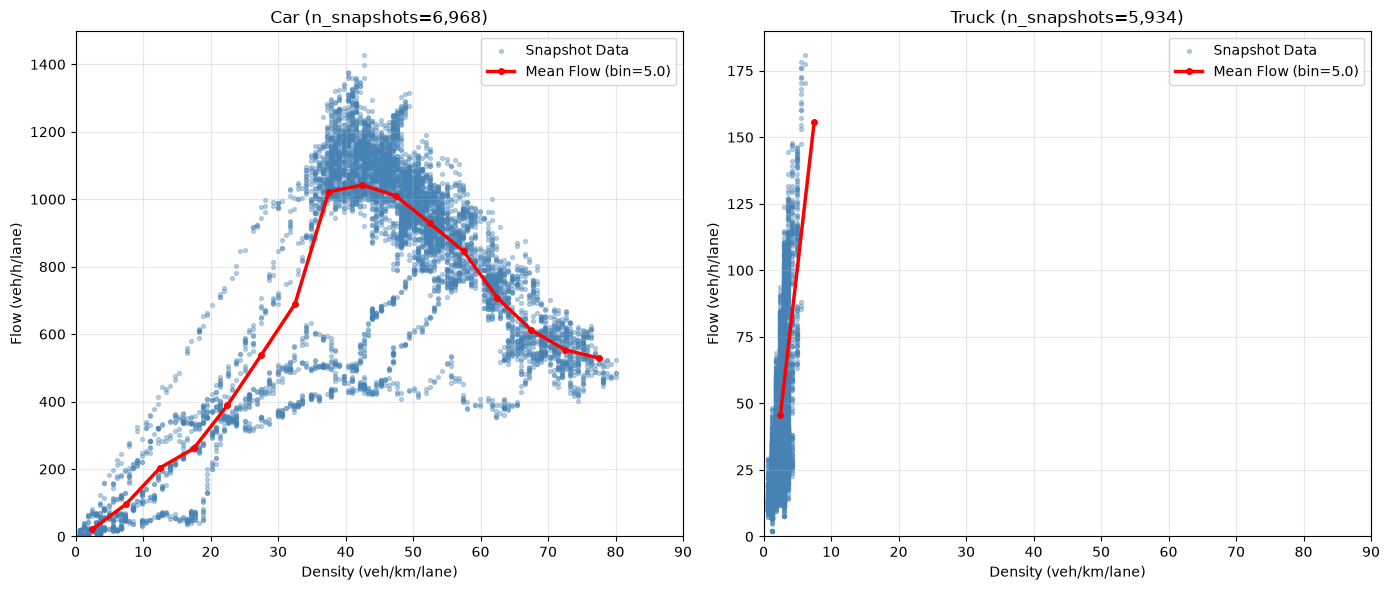

In [53]:
#フィルタリング前データ
snapshots = compute_macroscopic_data(df_clean, lanes=(2,3,4), classes=(2, 3), snapshot_step_frames=5)
#フィルタリング後データ
#snapshots = compute_macroscopic_data(df_mdensity, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)

plot_fundamental_diagram(snapshots, classes=(2, 3), max_density=90)